In [1]:
import pandas as pd

In [2]:
# Load the dataset
df = pd.read_csv("data/eda.csv")
df.head()

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
0,1,2018-05,5 ROOM,118,PASIR RIS ST 11,8.0,123.0,1989,70 years 03 months,488000.0,17,5,PASIR RIS,Improved
1,2,2016-10,4 ROOM,101,RIVERVALE WALK,2.0,100.0,1999,81,345000.0,21,8,SENGKANG,Model A
2,3,2018-10,5 ROOM,688A,CHOA CHU KANG DR,20.0,110.0,2002,82 years 06 months,370000.0,9,5,CHOA CHU KANG,Improved
3,4,2015-12,4 ROOM,130,LOR AH SOO,14.0,103.0,1984,67,432000.0,12,8,HOUGANG,Model A
4,5,2017-09,5 ROOM,533,SERANGOON NTH AVE 4,8.0,122.0,1992,74 years 02 months,500000.0,22,5,SERANGOON,Improved


## Data Cleaning

### Correcting Structural Errors

#### 1. Handling Negative Values

While exploring the `lease_commence_date` feature using the `.describe()` function in preliminary data exploration, I encountered some negative values. Since negative lease commencement year would not be unrealistic in the context of resale HDB flats, I made the assumption that these values were meant to be positive and use `.abs()` to correct them.

In [3]:
# Absolute negative years values
df['lease_commence_date'] = df['lease_commence_date'].abs()

#### 2. Standardising Categorical Labels

Another issue I noticed during the univariate analysis was an inconsistency in the `flat_type` feature. The data contained both '4 ROOM' and 'FOUR ROOM', which appeared to refer to the same flat type. I assumed this was a labelling inconsistency and standardised the values using `.replace()` to keep the categories consistent.

In [4]:
# Replace 'FOUR ROOM' with '4 ROOM' in the 'flat_type' column  
df['flat_type'] = df['flat_type'].replace('FOUR ROOM', '4 ROOM')

### Handling Missing Values

During preliminary data exploration, I noticed that after removing duplicates, `town_name` and `flatm_name` features had 741 and 488 missing values respectively.

To handle these missing values efficiently, I defined a reusable function below named `fill_missing_names` to fill in missing entries in `town_name` and `flatm_name` based on corresponding values in `town_id` and `flatm_id` respectively.

In [5]:
def fill_missing_names(df: pd.DataFrame, id_column: str, name_column: str) -> pd.DataFrame:
    """
    Fills missing values in the 'name_column' using the 'id_column'.

    Args:
        df (pd.DataFrame): The DataFrame containing the columns to be filled.
        id_column (str): The name of the column containing the IDs.
        name_column (str): The name of the column containing the names to be filled.

    Returns:
        pd.DataFrame: The DataFrame with missing values in 'name_column' filled.
    """
    # Identify missing values in the 'name_column'
    missing_names = df[name_column].isna()

    # Create a dictionary mapping 'id_column' to 'name_column'
    name_mapping = df[[id_column, name_column]].dropna().drop_duplicates().set_index(id_column)[name_column].to_dict()

    # Fill missing 'name_column' using the mapping
    df.loc[missing_names, name_column] = df.loc[missing_names, id_column].map(name_mapping)

    return df

In [6]:
# Fill missing values in 'town_name' column
df = fill_missing_names(df=df, id_column='town_id', name_column='town_name')

# Fill missing values in 'flatm_name' column
df = fill_missing_names(df=df, id_column='flatm_id', name_column='flatm_name')

### Removing Unnecessary Data

#### 1. Dropping Duplicates

During preliminary data exploration, I identified 4,223 duplicate rows by sorting and grouping duplicate records together, which let me confirm they were real duplicates rather than data entry errors. Once confirmed, I dropped them from the dataset in `eda.ipynb`.

#### 2. Dropping Irrelevant Features

The `id`, `town_id`, and `flatm_id` are not meaningful for predicting resale price, they are identifiers rather than predictive features, and keeping them would only add noise, increase computational cost, and potentially degrade model performance. Therefore, I dropped these irrelevant features.

In [7]:
# Drop irrelevant features
df = df.drop(columns=['id', 'town_id', 'flatm_id'])

## Feature Engineering

### Feature Engineering - 'month'

When I examined the `month` feature, it combines year and month into an object (string) column, like '2018-05', which isn't suitable for machine learning models that require numerical input.

In [8]:
# Convert 'month' column to datetime
df['year_month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Extract year and month from the datetime object
df['year'] = df['year_month'].dt.year
df['month'] = df['year_month'].dt.month

df.head()

,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_name,flatm_name,year_month,year
0,5,5 ROOM,118,PASIR RIS ST 11,8.0,123.0,1989,70 years 03 months,488000.0,PASIR RIS,Improved,2018-05-01,2018
1,10,4 ROOM,101,RIVERVALE WALK,2.0,100.0,1999,81,345000.0,SENGKANG,Model A,2016-10-01,2016
2,10,5 ROOM,688A,CHOA CHU KANG DR,20.0,110.0,2002,82 years 06 months,370000.0,CHOA CHU KANG,Improved,2018-10-01,2018
3,12,4 ROOM,130,LOR AH SOO,14.0,103.0,1984,67,432000.0,HOUGANG,Model A,2015-12-01,2015
4,9,5 ROOM,533,SERANGOON NTH AVE 4,8.0,122.0,1992,74 years 02 months,500000.0,SERANGOON,Improved,2017-09-01,2017


In [9]:
# Drop year_month
df = df.drop(columns=['year_month'])

### Feature Engineering - 'remaining_lease_months'

The `remaining_lease_months` column is currently stored as text and contains inconsistent formats, such as '70 years 03 months', '81', and '66 years'. To make this usable for machine learning, I'll convert all entries into a single standardized unit (total months).

In [10]:
import re

def extract_lease_info(lease_str: str) -> int:
    """
    Convert lease information from a string format to total months.

    This function takes a string representing the remaining lease period, which
    may include years and months in various formats (e.g., "70 years 3 months",
    "85 years", "67"), and converts it to the total number of months.

    Args:
        lease_str (str): The remaining lease period as a string.

    Returns:
        int: The total number of months, or None if the input is NaN.
    """

    if pd.isna(lease_str):
        return None
    
    # Regular expression to extract years and months
    years_match = re.search(r'(\d+)\s*years?', lease_str)
    months_match = re.search(r'(\d+)\s*months?', lease_str)
    number_match = re.match(r'^\d+$', lease_str.strip())
    
    if years_match:
        years = int(years_match.group(1))
    elif number_match:  # If only a number is present, assume it's in years
        years = int(number_match.group(0))
    else:
        years = 0
        
    months = int(months_match.group(1)) if months_match else 0
    
    # Convert the total lease period to months
    total_months = years * 12 + months
    return total_months

In [11]:
# Extract lease information  
df['remaining_lease_months'] = df['remaining_lease'].apply(extract_lease_info) 
# Display a random sample of the data to check the transformation
df[['remaining_lease', 'remaining_lease_months']].sample(5)

,remaining_lease,remaining_lease_months
72780,74 years 11 months,899
34007,82,984
72186,75 years 08 months,908
5003,74 years 05 months,893
65598,82 years,984


In [12]:
# Drop the 'remaining_lease' column
df = df.drop(columns=['remaining_lease'])

### Feature Engineering - 'storey_range'

Earlier in the Correlation Analysis section, I introduced a function called `convert_storey_range` to transform the original `storey_range` column from a string format into numerical values, so it could be used in the Spearman rank correlation analysis.

### Advanced Feature Engineering

I combined `block` and `street_name` into a new `full_address` column. This allows me to use Singapore's OneMap API to calculate the distance from each flat to relevant amenities, such as the nearest school, Mass Rapid Transit (MRT) station, and shopping mall. My domain knowledge suggests that proximity to these amenities significantly affects housing prices in Singapore.

In [13]:
df['full_address'] = df['block'] + ' ' + df['street_name']

In [14]:
# Drop the 'block' and 'street_name' columns
df = df.drop(columns=['block', 'street_name'])

In [15]:
# Export to csv file
df.to_csv("data/resale_transactions_v2.csv", index=False)

In [16]:
from scripts import get_address_coords

get_address_coords.main()

Saved 84465 rows to data/cleaned_resale_transactions.csv. 0 missing coordinates for address(es) were found.


In [17]:
df = pd.read_csv("data/cleaned_resale_transactions.csv")
df.head()

,month,flat_type,storey_range,floor_area_sqm,lease_commence_date,resale_price,town_name,flatm_name,year,remaining_lease_months,full_address,latitude,longitude
0,5,5 ROOM,8.0,123.0,1989,488000.0,PASIR RIS,Improved,2018,843,118 PASIR RIS ST 11,1.367149,103.954805
1,10,4 ROOM,2.0,100.0,1999,345000.0,SENGKANG,Model A,2016,972,101 RIVERVALE WALK,1.382764,103.899272
2,10,5 ROOM,20.0,110.0,2002,370000.0,CHOA CHU KANG,Improved,2018,990,688A CHOA CHU KANG DR,1.403964,103.750566
3,12,4 ROOM,14.0,103.0,1984,432000.0,HOUGANG,Model A,2015,804,130 LOR AH SOO,1.351280,103.886490
4,9,5 ROOM,8.0,122.0,1992,500000.0,SERANGOON,Improved,2017,890,533 SERANGOON NTH AVE 4,1.374536,103.874598


#### Retrieve Latitude and Longitude for all schools

In [18]:
from scripts import get_school_coords

get_school_coords.main()

Saved 359 institutions to data/school_coords.csv. 0 missing coordinates for institution(s) were found.


In [19]:
school_df = pd.read_csv("data/school_coords.csv")
school_df.head()

,school_name,latitude,longitude
0,Admiralty Primary School,1.442635,103.800040
1,Ahmad Ibrahim Primary School,1.433153,103.832942
2,Ai Tong School,1.360583,103.833020
3,Alexandra Primary School,1.291334,103.824425
4,Anchor Green Primary School,1.390370,103.887165


#### Retrieve Latitude and Longitude for all MRT/LRT stations

In [20]:
from scripts import get_station_coords

get_station_coords.main()

Saved 186 stations to data/station_coords.csv. 0 missing coordinates for station(s) were found.


In [21]:
station_df = pd.read_csv("data/station_coords.csv")
station_df.head()

,station_name,latitude,longitude
0,Jurong East (NS1),1.333028,103.742370
1,Bukit Batok (NS2),1.349033,103.749566
2,Bukit Gombak (NS3),1.358612,103.751791
3,Choa Chu Kang (NS4),1.385368,103.744085
4,Yew Tee (NS5),1.397535,103.747405


#### Retrieve Latitude and Longitude for all shopping malls

In [22]:
from scripts import get_mall_coords

get_mall_coords.main()

Saved 141 malls to data/mall_coords.csv. 0 missing coordinates for mall(s) were found.


In [23]:
mall_df = pd.read_csv("data/mall_coords.csv")
mall_df.head()

,mall_name,latitude,longitude
0,100 AM,1.274588,103.843471
1,313@Somerset,1.301014,103.838361
2,321 Clementi,1.312002,103.764987
3,600 @ Toa Payoh,1.334036,103.850978
4,888 Plaza,1.437705,103.795269


#### Distance to Nearest Amenities

I compute the distance from each flat to its nearest school, MRT/LRT station, and shopping mall using a KD-tree over each amenity's coordinates (much faster than comparing every flat against every amenity individually). Coordinates are converted to radians so the KD-tree's distance result can be converted into an accurate great-circle (haversine) distance in km.

In [24]:
import numpy as np
from scipy.spatial import cKDTree

def distance_to_nearest(df: pd.DataFrame, amenity_df: pd.DataFrame) -> pd.Series:
    """Return, for each row in df, the great-circle distance (m) to its nearest amenity."""
    EARTH_RADIUS_M = 6371000
    property_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
    amenity_rad = np.radians(amenity_df[["latitude", "longitude"]].to_numpy())
    tree = cKDTree(amenity_rad)
    chord_dist, _ = tree.query(property_rad, k=1)
    angular_dist = 2 * np.arcsin(chord_dist / 2)
    return pd.Series(angular_dist * EARTH_RADIUS_M, index=df.index)

In [25]:
df['distance_to_school'] = distance_to_nearest(df, school_df)
df['distance_to_mrt'] = distance_to_nearest(df, station_df)
df['distance_to_mall'] = distance_to_nearest(df, mall_df)

df[['distance_to_school', 'distance_to_mrt', 'distance_to_mall']].head()

,distance_to_school,distance_to_mrt,distance_to_mall
0,246.038467,639.602712,694.155720
1,181.817361,282.929658,728.841888
2,434.160991,796.596944,727.758783
3,156.233044,984.042903,886.398752
4,188.343937,1938.596051,557.617856


Dropping `full_address`, `latitude` and `longitude` columns because they are not meaningful for predicting resale price, they are identifiers rather than predictive features, and keeping them would only add noise, increase computational cost, and potentially degrade model performance. Therefore, I dropped these irrelevant features.

In [26]:
# Drop the 'full_address', 'latitude' and 'longitude' columns
df = df.drop(columns=['full_address', 'latitude', 'longitude'])

In [27]:
df.head()

,month,flat_type,storey_range,floor_area_sqm,lease_commence_date,resale_price,town_name,flatm_name,year,remaining_lease_months,distance_to_school,distance_to_mrt,distance_to_mall
0,5,5 ROOM,8.0,123.0,1989,488000.0,PASIR RIS,Improved,2018,843,246.038467,639.602712,694.155720
1,10,4 ROOM,2.0,100.0,1999,345000.0,SENGKANG,Model A,2016,972,181.817361,282.929658,728.841888
2,10,5 ROOM,20.0,110.0,2002,370000.0,CHOA CHU KANG,Improved,2018,990,434.160991,796.596944,727.758783
3,12,4 ROOM,14.0,103.0,1984,432000.0,HOUGANG,Model A,2015,804,156.233044,984.042903,886.398752
4,9,5 ROOM,8.0,122.0,1992,500000.0,SERANGOON,Improved,2017,890,188.343937,1938.596051,557.617856


In [28]:
df.to_csv("data/cleaned_resale_transactions_v2.csv", index=False)

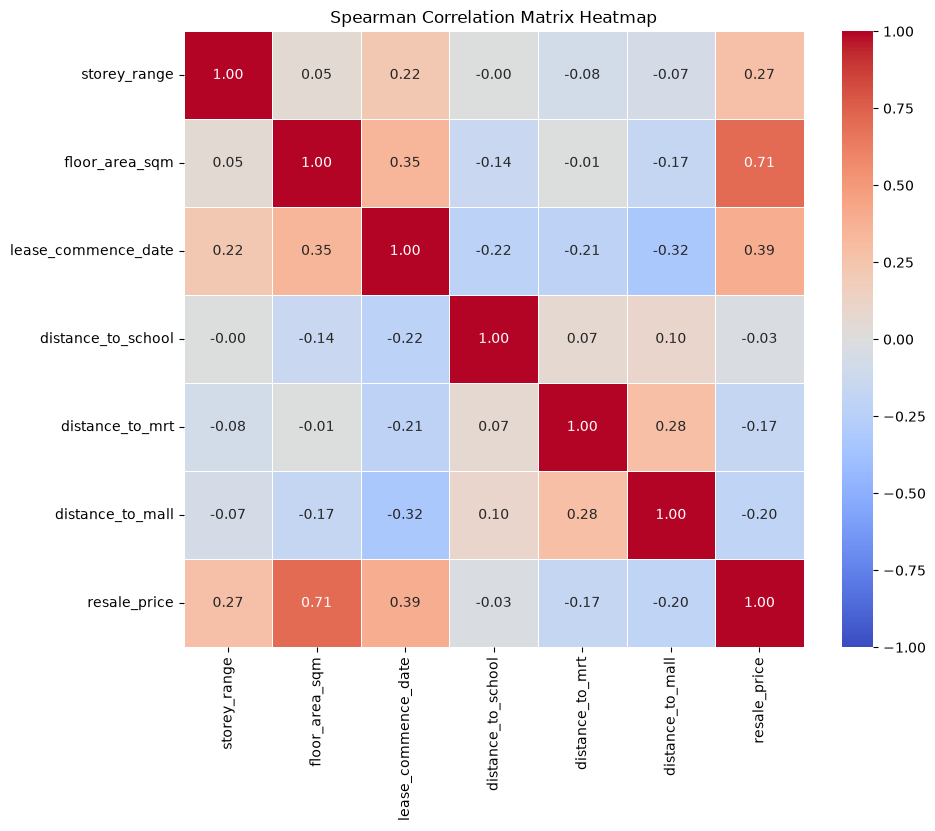

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns for correlation analysis
spearman_vars = df[['storey_range', 'floor_area_sqm', 'lease_commence_date', 'distance_to_school', 'distance_to_mrt', 'distance_to_mall', 'resale_price']]

# Compute the Spearman correlation matrix
spearman_corr = spearman_vars.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5, fmt=".2f")
plt.title('Spearman Correlation Matrix Heatmap')
plt.show()

1. There is a strong positive monotonic correlation between the `floor_area` and the `resale_price`. Larger flats tend to have higher resale prices, and this relationship is relatively strong.

2. There is a moderate positive monotonic relationship between the `lease_commence_date` and the `resale_price`. Flats with more recent lease commencement dates tend to have higher resale prices.

3. There is a weak positive monotonic correlation between the `storey_range` and the `resale_price`. Higher storey flats tend to have higher resale prices, but the relationship is not strong.

4. There is a weak negative monotonic correlation between the `distance_to_mrt` and the `resale_price`. Flats located closer to an MRT station tend to have higher resale prices, but the relationship is not strong.

5. There is a weak negative monotonic correlation between the `distance_to_mall` and the `resale_price`. Flats located closer to a shopping mall tend to have slightly higher resale prices, but the relationship is weak.

6. There is a negligible correlation between the `distance_to_school` and the `resale_price`. Proximity to a school does not appear to meaningfully influence resale price in this dataset.